In [5]:
import pandas as pd 
df=pd.read_excel('premiums_with_life_style.xlsx')
display(df.head())

,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


In [6]:
print(df.shape)

(10000, 15)


In [7]:
df.columns.str.replace(' ','_').str.lower()

Index(['age', 'gender', 'region', 'marital_status', 'physical_activity',
       'stress_level', 'number_of_dependants', 'bmi_category',
       'smoking_status', 'employment_status', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount'],
      dtype='object')

In [8]:
df.columns=df.columns.str.replace(' ','_').str.lower()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    10000 non-null  int64 
 1   gender                 10000 non-null  object
 2   region                 10000 non-null  object
 3   marital_status         10000 non-null  object
 4   physical_activity      10000 non-null  object
 5   stress_level           10000 non-null  object
 6   number_of_dependants   10000 non-null  int64 
 7   bmi_category           10000 non-null  object
 8   smoking_status         9991 non-null   object
 9   employment_status      9993 non-null   object
 10  income_level           9982 non-null   object
 11  income_lakhs           10000 non-null  int64 
 12  medical_history        10000 non-null  object
 13  insurance_plan         10000 non-null  object
 14  annual_premium_amount  10000 non-null  int64 
dtypes: int64(4), object(

In [10]:
df.isnull().sum()

age                       0
gender                    0
region                    0
marital_status            0
physical_activity         0
stress_level              0
number_of_dependants      0
bmi_category              0
smoking_status            9
employment_status         7
income_level             18
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
physical_activity        0
stress_level             0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [13]:
df.duplicated().sum() ## finding the dupliacte rows in a dataframe

np.int64(0)

In [14]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9973.000000,9973.000000,9973.000000,9973.000000
mean,41.319362,3.195628,23.382232,19503.816705
std,58.044687,21.679565,32.334811,8898.079736
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11774.000000
50%,37.000000,2.000000,16.000000,19314.000000
75%,50.000000,3.000000,31.000000,26500.000000
max,1178.000000,456.000000,960.000000,45854.000000


### Drawing a Boxplot for detecting the Outliers

In [15]:
numeric_cols=df.select_dtypes(['float64','int64']).columns
print(numeric_cols)

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')


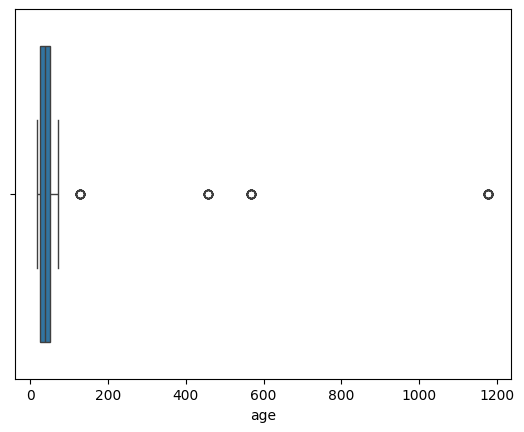

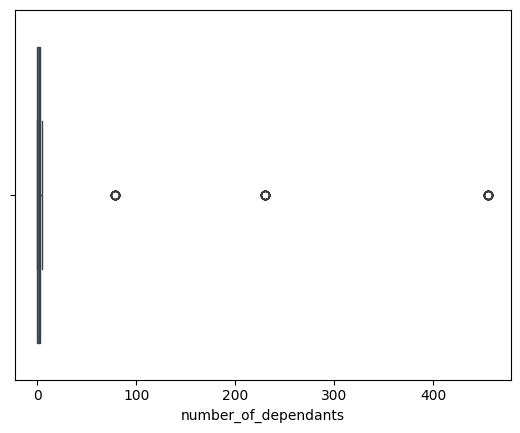

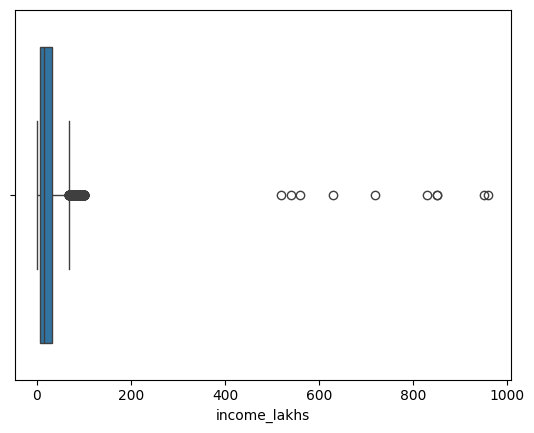

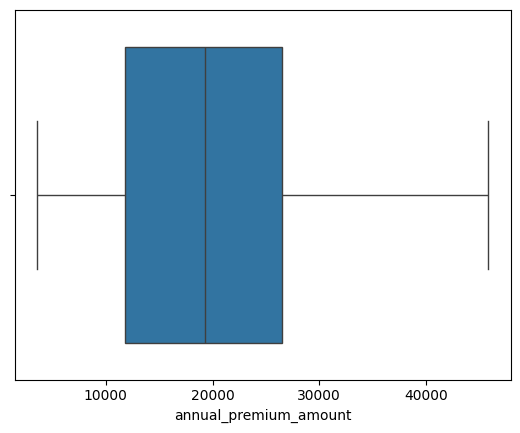

In [16]:
import seaborn as sns 
import matplotlib.pyplot as plt
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.show()

### Removing of Outliers

#### Removing outliers in Age column

In [17]:
df1=df[df['age']<100].copy() 
display(df1.head(10))

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984
5,33,Female,Northwest,Unmarried,Low,High,0,Normal,Regular,Freelancer,<10L,1,No Disease,Gold,28388
6,53,Female,Northwest,Unmarried,Medium,Medium,0,Overweight,No Smoking,Self-Employed,<10L,6,No Disease,Silver,20959
7,39,Female,Northwest,Married,High,Medium,3,Obesity,No Smoking,Salaried,10L - 25L,21,Diabetes & Thyroid,Silver,22640
8,42,Female,Southeast,Unmarried,Low,Medium,1,Normal,Occasional,Self-Employed,<10L,6,Thyroid,Silver,19319
9,42,Female,Northwest,Married,Medium,Medium,4,Normal,Occasional,Self-Employed,10L - 25L,18,Diabetes,Silver,19150


In [18]:
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9915.000000,9915.000000,9915.000000,9915.000000
mean,37.743621,3.203429,23.400807,19496.715784
std,13.975462,21.742340,32.398236,8899.088302
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11765.500000
50%,37.000000,2.000000,16.000000,19309.000000
75%,50.000000,3.000000,31.000000,26493.000000
max,72.000000,456.000000,960.000000,45854.000000


### Removing Outliers in income_lakhs column

In [19]:
q3=df1['income_lakhs'].quantile(0.75) 
q1=df1['income_lakhs'].quantile(0.25) 
print(q3)
print(q1)

31.0
6.0


In [20]:
def iqr(col):
    iqr=q3-q1 
    upper_quartile=q3+1.5*iqr
    lower_quartile=q1-1.5*iqr
    return upper_quartile,lower_quartile
iqr(df1['income_lakhs'])

(np.float64(68.5), np.float64(-31.5))

In [21]:
df1[df1['income_lakhs']>68.5]['income_lakhs'].count()

np.int64(697)

##### Here we can see total 697 members are having higher income than upper_quantile

<Axes: >

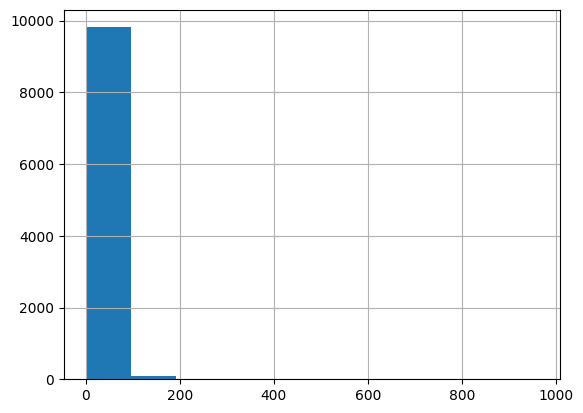

In [22]:
df1['income_lakhs'].hist()

#### According to outliers method we want to remove 697 rows but this is not possible.Instead of that we can set quartile is 0.99

In [23]:
income_threshold=df1['income_lakhs'].quantile(0.99)
income_threshold

np.float64(97.0)

##### here we can say that 99% of data falls below the 97.0 lakhs

In [24]:
df2=df1[df1['income_lakhs']<=income_threshold].copy()

In [25]:
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9839.000000,9839.000000,9839.000000,9839.000000
mean,37.743673,3.214758,22.163228,19476.128163
std,13.970373,21.825355,21.634341,8898.158197
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11748.000000
50%,37.000000,2.000000,16.000000,19292.000000
75%,50.000000,3.000000,31.000000,26465.500000
max,72.000000,456.000000,97.000000,45854.000000


#### No.of Dependents Column

In [26]:
q3=df2['income_lakhs'].quantile(0.75) 
q1=df2['income_lakhs'].quantile(0.25) 
def iqr(col):
    iqr=q3-q1 
    upper_quartile=q3+1.5*iqr
    lower_quartile=q1-1.5*iqr
    return upper_quartile,lower_quartile
iqr(df2['number_of_dependants'])

(np.float64(68.5), np.float64(-31.5))

In [27]:
df2[df2['number_of_dependants']>68.5]['number_of_dependants'].count()

np.int64(47)

In [28]:
dependent_threshold=df2['number_of_dependants'].quantile(0.99)
dependent_threshold

np.float64(5.0)

In [29]:
df3=df2[df2['number_of_dependants']<=dependent_threshold].copy()

In [30]:
df3.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9792.000000,9792.000000,9792.000000,9792.000000
mean,37.756638,1.920547,22.168199,19490.845384
std,13.971721,1.502872,21.629748,8900.055780
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11756.750000
50%,37.000000,2.000000,16.000000,19309.500000
75%,50.000000,3.000000,31.000000,26485.250000
max,72.000000,5.000000,97.000000,45854.000000


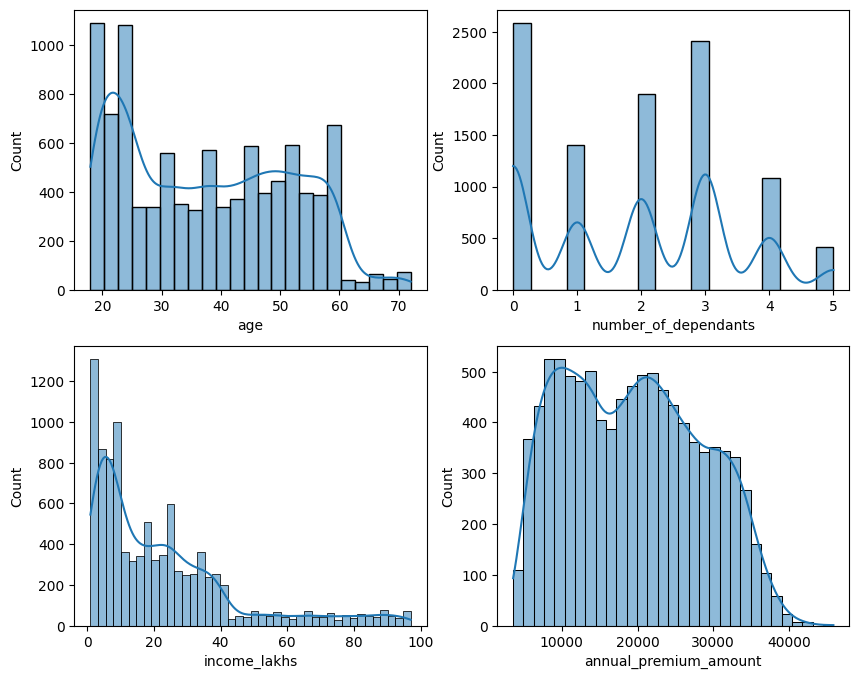

In [31]:
fig, axes = plt.subplots(2,2, figsize=(10, 8))

axes = axes.flatten()  # convert to 1D array

for i, col in enumerate(numeric_cols):
    sns.histplot(x=df3[col], ax=axes[i],kde=True)

In [32]:
categorical_col=df3.select_dtypes(exclude=['int64','float64']).columns
categorical_col

Index(['gender', 'region', 'marital_status', 'physical_activity',
       'stress_level', 'bmi_category', 'smoking_status', 'employment_status',
       'income_level', 'medical_history', 'insurance_plan'],
      dtype='object')

In [33]:
for col in categorical_col:
    print(col," column unique values are:",df3[col].unique())

gender  column unique values are: ['Female' 'Male']
region  column unique values are: ['Southeast' 'Northeast' 'Southwest' 'Northwest']
marital_status  column unique values are: ['Unmarried' 'Married']
physical_activity  column unique values are: ['Medium' 'Low' 'High']
stress_level  column unique values are: ['Medium' 'High' 'Low']
bmi_category  column unique values are: ['Normal' 'Overweight' 'Obesity' 'Underweight']
smoking_status  column unique values are: ['No Smoking' 'Occasional' 'Regular']
employment_status  column unique values are: ['Self-Employed' 'Freelancer' 'Salaried']
income_level  column unique values are: ['25L - 40L' '10L - 25L' '<10L' '> 40L']
medical_history  column unique values are: ['High blood pressure' 'No Disease' 'Thyroid'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid' 'Diabetes'
 'Heart disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease']
insurance_plan  column unique values are: ['Gold' 'Silver' 'Bronze']


In [34]:
display(df3.head())

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


In [35]:
pd.crosstab(df3['employment_status'],df3['insurance_plan'])

insurance_plan,Bronze,Gold,Silver
employment_status,,,
Freelancer,1303,486,870
Salaried,1658,908,1549
Self-Employed,713,1184,1121


In [36]:
pd.crosstab(df3['income_level'],df3['insurance_plan'])

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,822,909,998
25L - 40L,533,733,733
<10L,2266,184,1366
> 40L,53,752,443


<Axes: xlabel='marital_status', ylabel='annual_premium_amount'>

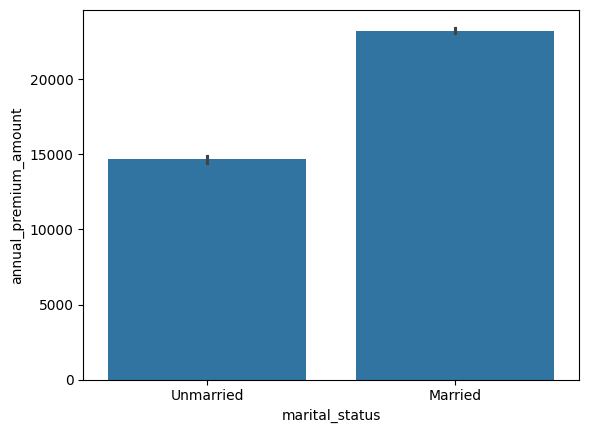

In [37]:
sns.barplot(data=df3,x='marital_status',y='annual_premium_amount')

<Axes: xlabel='age', ylabel='insurance_plan'>

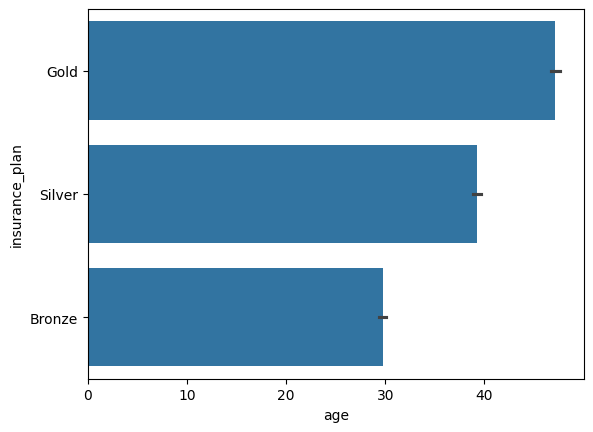

In [38]:
sns.barplot(data=df3,x='age',y='insurance_plan')

In [39]:
df3['medical_history'].unique()

array(['High blood pressure', 'No Disease', 'Thyroid',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes', 'Heart disease', 'Diabetes & High blood pressure',
       'Diabetes & Heart disease'], dtype=object)

In [40]:
df3[['disease1','disease2']]=df3['medical_history'].str.split("&",expand=True).apply(lambda x:x.str.lower())

In [41]:
display(df3.head())

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,high blood pressure,None
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,no disease,None
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459,no disease,None
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685,thyroid,None
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,high blood pressure,heart disease


In [42]:
import warnings 
warnings.filterwarnings('ignore')
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df3[['disease1', 'disease2']] = df3['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df3['disease1'].fillna('none', inplace=True)
df3['disease2'].fillna('none', inplace=True)
df3['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df3['total_risk_score'] += df3[disease].map(risk_scores)

# Normalize the risk score to a range of 0 to 1
max_score = df3['total_risk_score'].max()
min_score = df3['total_risk_score'].min()
df3['normalized_risk_score'] = (df3['total_risk_score'] - min_score) / (max_score - min_score)
df3.head(2)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,high blood pressure,none,6,0.428571
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,no disease,none,0,0.000000


In [43]:
df3['physical_activity'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [44]:
df3['stress_level'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [45]:
df3['physical_activity']=df3['physical_activity'].map({'Low':0,'Medium':1,'High':2}) 
df3['stress_level']=df3['stress_level'].map({'Low':0,'Medium':1,'High':2}) 
df3['insurance_plan']=df3['insurance_plan'].map({'Bronze':0,'Silver':1,'Gold':2})

In [46]:
display(df3.head())

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,56,Female,Southeast,Unmarried,1,1,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,2,27944,high blood pressure,none,6,0.428571
1,38,Female,Northeast,Married,0,2,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,1,21108,no disease,none,0,0.000000
2,18,Female,Southwest,Unmarried,1,2,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,0,8459,no disease,none,0,0.000000
3,55,Male,Northeast,Married,2,1,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,1,21685,thyroid,none,5,0.357143
4,22,Male,Southeast,Unmarried,1,2,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,0,15984,high blood pressure,heart disease,14,1.000000


In [47]:
print(df3['gender'].unique())
print(df3['marital_status'].unique())

['Female' 'Male']
['Unmarried' 'Married']


In [48]:
df3['gender']=df3['gender'].map({'Male':0,'Female':1}) 
df3['marital_status']=df3['marital_status'].map({'Unmarried':0,'Married':1}) 

In [49]:
display(df3.head())

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,56,1,Southeast,0,1,1,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,2,27944,high blood pressure,none,6,0.428571
1,38,1,Northeast,1,0,2,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,1,21108,no disease,none,0,0.000000
2,18,1,Southwest,0,1,2,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,0,8459,no disease,none,0,0.000000
3,55,0,Northeast,1,2,1,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,1,21685,thyroid,none,5,0.357143
4,22,0,Southeast,0,1,2,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,0,15984,high blood pressure,heart disease,14,1.000000


In [50]:
df3['income_level'].unique()

array(['25L - 40L', '10L - 25L', '<10L', '> 40L'], dtype=object)

In [51]:
df3['income_level']=df3['income_level'].map({'<10L':0,'10L - 25L':1,'25L - 40L':2,'> 40L':3})
display(df3.head(2))

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,56,1,Southeast,0,1,1,2,Normal,No Smoking,Self-Employed,2,37,High blood pressure,2,27944,high blood pressure,none,6,0.428571
1,38,1,Northeast,1,0,2,5,Overweight,Occasional,Freelancer,1,10,No Disease,1,21108,no disease,none,0,0.000000


In [52]:
nominal_col=['region','bmi_category','smoking_status','employment_status']
df4=pd.get_dummies(df3,columns=nominal_col,dtype='int',drop_first=True)
display(df4)

,age,gender,marital_status,physical_activity,stress_level,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,...,region_Northwest,region_Southeast,region_Southwest,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,56,1,0,1,1,2,2,37,High blood pressure,2,...,0,1,0,0,0,0,0,0,0,1
1,38,1,1,0,2,5,1,10,No Disease,1,...,0,0,0,0,1,0,1,0,0,0
2,18,1,0,1,2,0,0,9,No Disease,0,...,0,0,1,0,0,0,0,0,0,0
3,55,0,1,2,1,3,0,9,Thyroid,1,...,0,0,0,0,1,0,1,0,1,0
4,22,0,0,1,2,2,1,13,High blood pressure & Heart disease,0,...,0,1,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,31,0,1,1,1,5,1,13,Diabetes,1,...,0,0,0,0,1,0,0,1,0,0
9996,24,0,0,2,1,0,2,29,High blood pressure,0,...,0,0,1,0,0,1,0,0,0,0
9997,18,0,0,1,2,0,0,6,No Disease,1,...,0,1,0,0,0,1,0,1,0,0
9998,28,1,0,2,0,0,2,27,Diabetes,2,...,1,0,0,0,1,0,1,0,0,1


In [53]:
df4.columns

Index(['age', 'gender', 'marital_status', 'physical_activity', 'stress_level',
       'number_of_dependants', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'disease1', 'disease2', 'total_risk_score', 'normalized_risk_score',
       'region_Northwest', 'region_Southeast', 'region_Southwest',
       'bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

In [54]:
df5=df4.drop(['medical_history','disease1', 'disease2', 'total_risk_score'],axis=1)
display(df5.head(2))

,age,gender,marital_status,physical_activity,stress_level,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,...,region_Northwest,region_Southeast,region_Southwest,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,56,1,0,1,1,2,2,37,2,27944,...,0,1,0,0,0,0,0,0,0,1
1,38,1,1,0,2,5,1,10,1,21108,...,0,0,0,0,1,0,1,0,0,0


In [55]:
from sklearn.preprocessing import MinMaxScaler 
col_scale=['age','physical_activity','stress_level','number_of_dependants','income_level','income_lakhs','insurance_plan']
X=df5.drop('annual_premium_amount',axis=1) 
scaler=MinMaxScaler()
X[col_scale]=scaler.fit_transform(X[col_scale])
display(X.head())

,age,gender,marital_status,physical_activity,stress_level,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,region_Northwest,region_Southeast,region_Southwest,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.703704,1,0,0.5,0.5,0.4,0.666667,0.375000,1.0,0.428571,0,1,0,0,0,0,0,0,0,1
1,0.370370,1,1,0.0,1.0,1.0,0.333333,0.093750,0.5,0.000000,0,0,0,0,1,0,1,0,0,0
2,0.000000,1,0,0.5,1.0,0.0,0.000000,0.083333,0.0,0.000000,0,0,1,0,0,0,0,0,0,0
3,0.685185,0,1,1.0,0.5,0.6,0.000000,0.083333,0.5,0.357143,0,0,0,0,1,0,1,0,1,0
4,0.074074,0,0,0.5,1.0,0.4,0.333333,0.125000,0.0,1.000000,0,1,0,0,0,0,0,1,0,1


In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif_data(data):
    vif_df=pd.DataFrame()
    vif_df['column']=data.columns
    vif_df['VIF']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])] 
    return vif_df

In [57]:
calculate_vif_data(X)

,column,VIF
0,age,5.883662
1,gender,2.517019
2,marital_status,8.727814
3,physical_activity,2.710966
4,stress_level,3.080371
5,number_of_dependants,8.627255
6,income_level,12.910917
7,income_lakhs,11.603229
8,insurance_plan,4.122986
9,normalized_risk_score,3.053950


In [58]:
calculate_vif_data(X.drop(['number_of_dependants','income_level'],axis=1))

,column,VIF
0,age,5.811661
1,gender,2.506680
2,marital_status,3.362868
3,physical_activity,2.705054
4,stress_level,3.069057
5,income_lakhs,2.428611
6,insurance_plan,3.869212
7,normalized_risk_score,3.047403
8,region_Northwest,1.883602
9,region_Southeast,2.582154


In [59]:
X_reduced=X.drop(['number_of_dependants','income_level'],axis=1)

### Training_Testing_splitting

In [60]:
from sklearn.model_selection import train_test_split 
y=df5['annual_premium_amount']
X_train,X_test,y_train,y_test=train_test_split(X_reduced,y,test_size=0.3,random_state=42)
print("X-train shape is:",X_train.shape)
print("X-test shape is:",X_test.shape)
print("y-train shape is:",y_train.shape)
print("y-test shape is:",y_test.shape)

X-train shape is: (6854, 18)
X-test shape is: (2938, 18)
y-train shape is: (6854,)
y-test shape is: (2938,)


### Linear Regression

In [61]:
from sklearn.linear_model import LinearRegression 
model1=LinearRegression() 
model1.fit(X_train,y_train)

LinearRegression()

In [62]:
print("training score is:",model1.score(X_train,y_train)) 
print("testing score is:",model1.score(X_test,y_test))

training score is: 0.9569857269817666
testing score is: 0.9527842120711086


In [63]:
from sklearn.linear_model import Ridge 
ridge=Ridge() 
ridge.fit(X_train,y_train) 
print(ridge.score(X_train,y_train))
print(ridge.score(X_test,y_test))

0.9569848536860706
0.9527687596766707


### Decison Tree regressor and SVM Regressor

In [64]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
model_params={
    'decisiontree':{
        'model':DecisionTreeRegressor(),
        'params':{
            'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
            'max_depth':[5,10,15],
            'max_features':[None,'sqrt','log2']
        }
    },
    'svm':{
        'model':SVR(),
         'params': {
            'kernel': ['linear', 'rbf'],
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto']
        }
    }
}

In [65]:
from sklearn.model_selection import GridSearchCV
scores=[]
for key,val in model_params.items():
    clf=GridSearchCV(val['model'],val['params'],cv=5,return_train_score=False)
    clf.fit(X_train,y_train)
    #scores.append({'model':key,'best_score':clf.best_score_,'best_params':clf.best_params_})
    best_model=clf.best_estimator_
    training_score=best_model.score(X_train,y_train) 
    testing_score=best_model.score(X_test,y_test) 
    scores.append({'model':key,'best_score':clf.best_score_,'best_params':clf.best_params_,
                   'trainig_score':training_score,'testing_score':testing_score})
    


In [66]:
scores_df=pd.DataFrame(scores)
display(scores_df)

,model,best_score,best_params,trainig_score,testing_score
0,decisiontree,0.981805,"{'criterion': 'friedman_mse', 'max_depth': 15,...",0.998817,0.982050
1,svm,0.952987,"{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}",0.953396,0.947141


In [67]:
print(clf.best_estimator_)
print(clf.best_params_)

SVR(C=100, kernel='linear')
{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}


### XGBOOST

In [68]:
from xgboost import XGBRegressor 
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search =GridSearchCV(model_xgb, param_grid, cv=5, scoring='r2')
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.994465970993042)

In [69]:
model_xgb.fit(X_train,y_train)
print(model_xgb.score(X_train,y_train)) 
print(model_xgb.score(X_test,y_test)) 

0.9979583024978638
0.9934909343719482


In [70]:
from sklearn.metrics import mean_squared_error
import numpy as np 
y_pred=model_xgb.predict(X_test) 
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse) 
print("mse value is:",mse) 
print("rmse value is:",rmse)

mse value is: 499877.6246040511
rmse value is: 707.0202434188509


In [71]:
best_model=random_search.best_estimator_
print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)


In [72]:
feature_imp=best_model.feature_importances_
print(feature_imp)

[2.0368460e-01 2.9293826e-04 1.9260672e-04 1.0467298e-02 1.2151688e-02
 2.0545606e-04 6.7035174e-01 2.6099749e-02 1.5568890e-04 1.8969760e-04
 1.3647924e-04 2.7679721e-02 1.7285723e-02 2.0719601e-03 3.9542732e-03
 2.4748657e-02 1.5697539e-04 1.7458308e-04]


In [73]:
coef_df=pd.DataFrame(feature_imp,index=X_train.columns,columns=['coefficient'])
display(coef_df)

,coefficient
age,0.203685
gender,0.000293
marital_status,0.000193
physical_activity,0.010467
stress_level,0.012152
income_lakhs,0.000205
insurance_plan,0.670352
normalized_risk_score,0.026100
region_Northwest,0.000156
region_Southeast,0.000190


<BarContainer object of 18 artists>

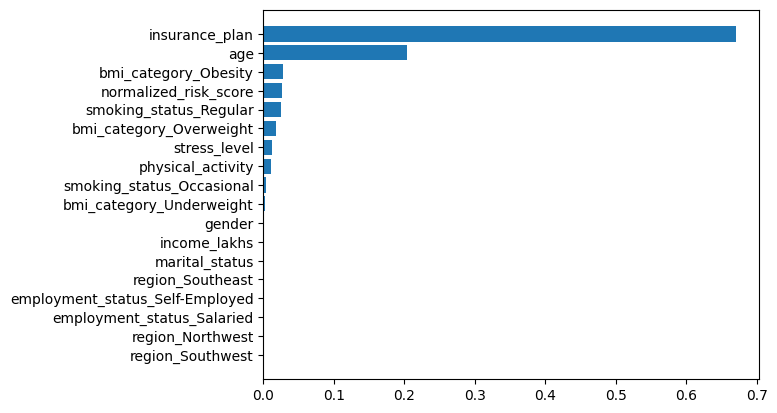

In [74]:
coef_df = coef_df.sort_values(by='coefficient', ascending=True)
plt.barh(coef_df.index,coef_df['coefficient'])

In [75]:
y_pred=best_model.predict(X_test) 
residuals=y_pred-y_test
residuals_pct=residuals*100/y_test
results_df=pd.DataFrame({'actual_values':y_test,'predicted_values':y_pred,'residuals':residuals,
                         'residuals_pct':residuals_pct})
display(results_df.head(8))

,actual_values,predicted_values,residuals,residuals_pct
6686,21000,21654.533203,654.533203,3.116825
6965,16222,16933.326172,711.326172,4.384947
8077,33532,33980.296875,448.296875,1.336923
3055,5825,5811.265137,-13.734863,-0.235792
7811,13685,13657.980469,-27.019531,-0.197439
5516,12843,12248.193359,-594.806641,-4.631368
40,7670,6783.270996,-886.729004,-11.561004
3250,9628,8732.429688,-895.570312,-9.301727


<Axes: xlabel='residuals_pct', ylabel='Count'>

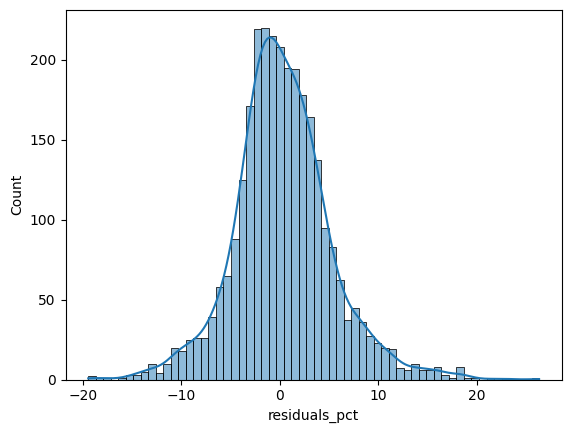

In [76]:
sns.histplot(results_df['residuals_pct'],kde=True)

In [77]:
extreme_results=results_df[np.abs(results_df['residuals_pct'])>10]
display(extreme_results)

,actual_values,predicted_values,residuals,residuals_pct
40,7670,6783.270996,-886.729004,-11.561004
4801,12349,11071.627930,-1277.372070,-10.343931
2522,8899,7913.847168,-985.152832,-11.070377
8183,5240,5826.051270,586.051270,11.184185
1560,9762,8549.020508,-1212.979492,-12.425522
...,...,...,...,...
2452,6295,5574.163086,-720.836914,-11.450944
7778,10076,9028.676758,-1047.323242,-10.394236
4716,7627,8569.399414,942.399414,12.356096
7706,5983,5130.968262,-852.031738,-14.240878


In [78]:
print(results_df.shape)

(2938, 4)


In [79]:
extreme_errors_pct = extreme_results.shape[0]*100/X_test.shape[0]
extreme_errors_pct

5.888359428182437

In [82]:
from joblib import dump 
dump(best_model,'C:/Users/ravit/Downloads/ML Projects/Regression/Artifacts/Regression_model.joblib')
scaler_with_col={
    'scaler':scaler,
    'cols_to_scale':col_scale
}
dump(best_model,'C:/Users/ravit/Downloads/ML Projects/Regression/Artifacts/scaler_with_col.joblib')

['C:/Users/ravit/Downloads/ML Projects/Regression/Artifacts/scaler_with_col.joblib']